# Linear Regression

**Algorithm:** Linear Regression

**Type:** Supervised Learning

**Problem:** Regression

**Dataset:** laptopPrice.csv

**Language:** Python

**Libraries:** Pandas, NumPy, Matplotlib, Scikit-learn

**Author:** Adeela Saleem

Libraries

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [84]:
from google.colab import files
uploaded=files.upload()

Saving laptopPrice.csv to laptopPrice (2).csv


In [85]:
df=pd.read_csv('laptopPrice.csv')

In [86]:
corr = df.corr(numeric_only=True)['Price'].sort_values(ascending=False)
print(corr)

Price                1.000000
Number of Ratings   -0.140392
Number of Reviews   -0.148738
Name: Price, dtype: float64


Basic Info

In [87]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [88]:
df.columns

Index(['brand', 'processor_brand', 'processor_name', 'processor_gnrtn',
       'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb',
       'weight', 'warranty', 'Touchscreen', 'msoffice', 'Price', 'rating',
       'Number of Ratings', 'Number of Reviews'],
      dtype='object')

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

In [90]:
df.describe()

,Price,Number of Ratings,Number of Reviews
count,823.000000,823.000000,823.000000
mean,76745.177400,315.301337,37.609964
std,45101.790525,1047.382654,121.728017
min,16990.000000,0.000000,0.000000
25%,46095.000000,0.000000,0.000000
50%,64990.000000,17.000000,2.000000
75%,89636.000000,139.500000,18.000000
max,441990.000000,15279.000000,1947.000000


In [91]:
df.isnull().sum()

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,0
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


In [92]:
df.duplicated().sum()

np.int64(21)

In [93]:
#remove dupliactes
df.drop_duplicates(inplace=True)

In [94]:
df.duplicated().sum()

np.int64(0)

Convert fake-object (4 GB-->4 like)

In [95]:
df.head(2)

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5


regex=False means searching for exact literal text, disabling special regular expression formulas and pattern matching codes.

In [96]:
df['processor_gnrtn'] = df['processor_gnrtn'].str.replace('th', '', regex=False)
df['processor_gnrtn'] = pd.to_numeric(df['processor_gnrtn'], errors='coerce')

In [97]:
# ram_gb - "4 GB" -> 4
df['ram_gb'] = df['ram_gb'].str.replace('GB', '', regex=False).astype('int32')

In [98]:
# hdd - "1024 GB" -> 1024
df['hdd'] = df['hdd'].str.replace('GB', '', regex=False).astype('int32')


In [99]:
# os_bit - "64-bit" -> 64
df['os_bit'] = df['os_bit'].str.replace('-bit', '', regex=False).astype('int32')


In [100]:
# ssd - "512 GB" -> 512
df['ssd'] = df['ssd'].astype(str).str.replace('GB', '', regex=False)
df['ssd'] = pd.to_numeric(df['ssd'], errors='coerce').astype('int32')

In [101]:
# graphic_card_gb - "0 GB" -> 0
df['graphic_card_gb'] = df['graphic_card_gb'].str.replace('GB', '', regex=False).astype('int32')


In [102]:
# rating - "3 stars" -> 3
df['rating'] = df['rating'].str.replace(' stars', '', regex=False).str.replace(' star', '', regex=False)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [103]:
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['processor_gnrtn', 'ram_gb', 'ssd', 'hdd', 'os_bit', 'graphic_card_gb', 'Price', 'rating', 'Number of Ratings', 'Number of Reviews']
Categorical: ['brand', 'processor_brand', 'processor_name', 'ram_type', 'os', 'weight', 'warranty', 'Touchscreen', 'msoffice']


In [104]:
df.isnull().sum()

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,224
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              802 non-null    object 
 1   processor_brand    802 non-null    object 
 2   processor_name     802 non-null    object 
 3   processor_gnrtn    578 non-null    float64
 4   ram_gb             802 non-null    int32  
 5   ram_type           802 non-null    object 
 6   ssd                802 non-null    int32  
 7   hdd                802 non-null    int32  
 8   os                 802 non-null    object 
 9   os_bit             802 non-null    int32  
 10  graphic_card_gb    802 non-null    int32  
 11  weight             802 non-null    object 
 12  warranty           802 non-null    object 
 13  Touchscreen        802 non-null    object 
 14  msoffice           802 non-null    object 
 15  Price              802 non-null    int64  
 16  rating             802 non-null

In [106]:
df['ssd'].unique()

array([   0,  512,  256,  128, 1024, 2048, 3072], dtype=int32)

## **EDA**

Univariant Analysis

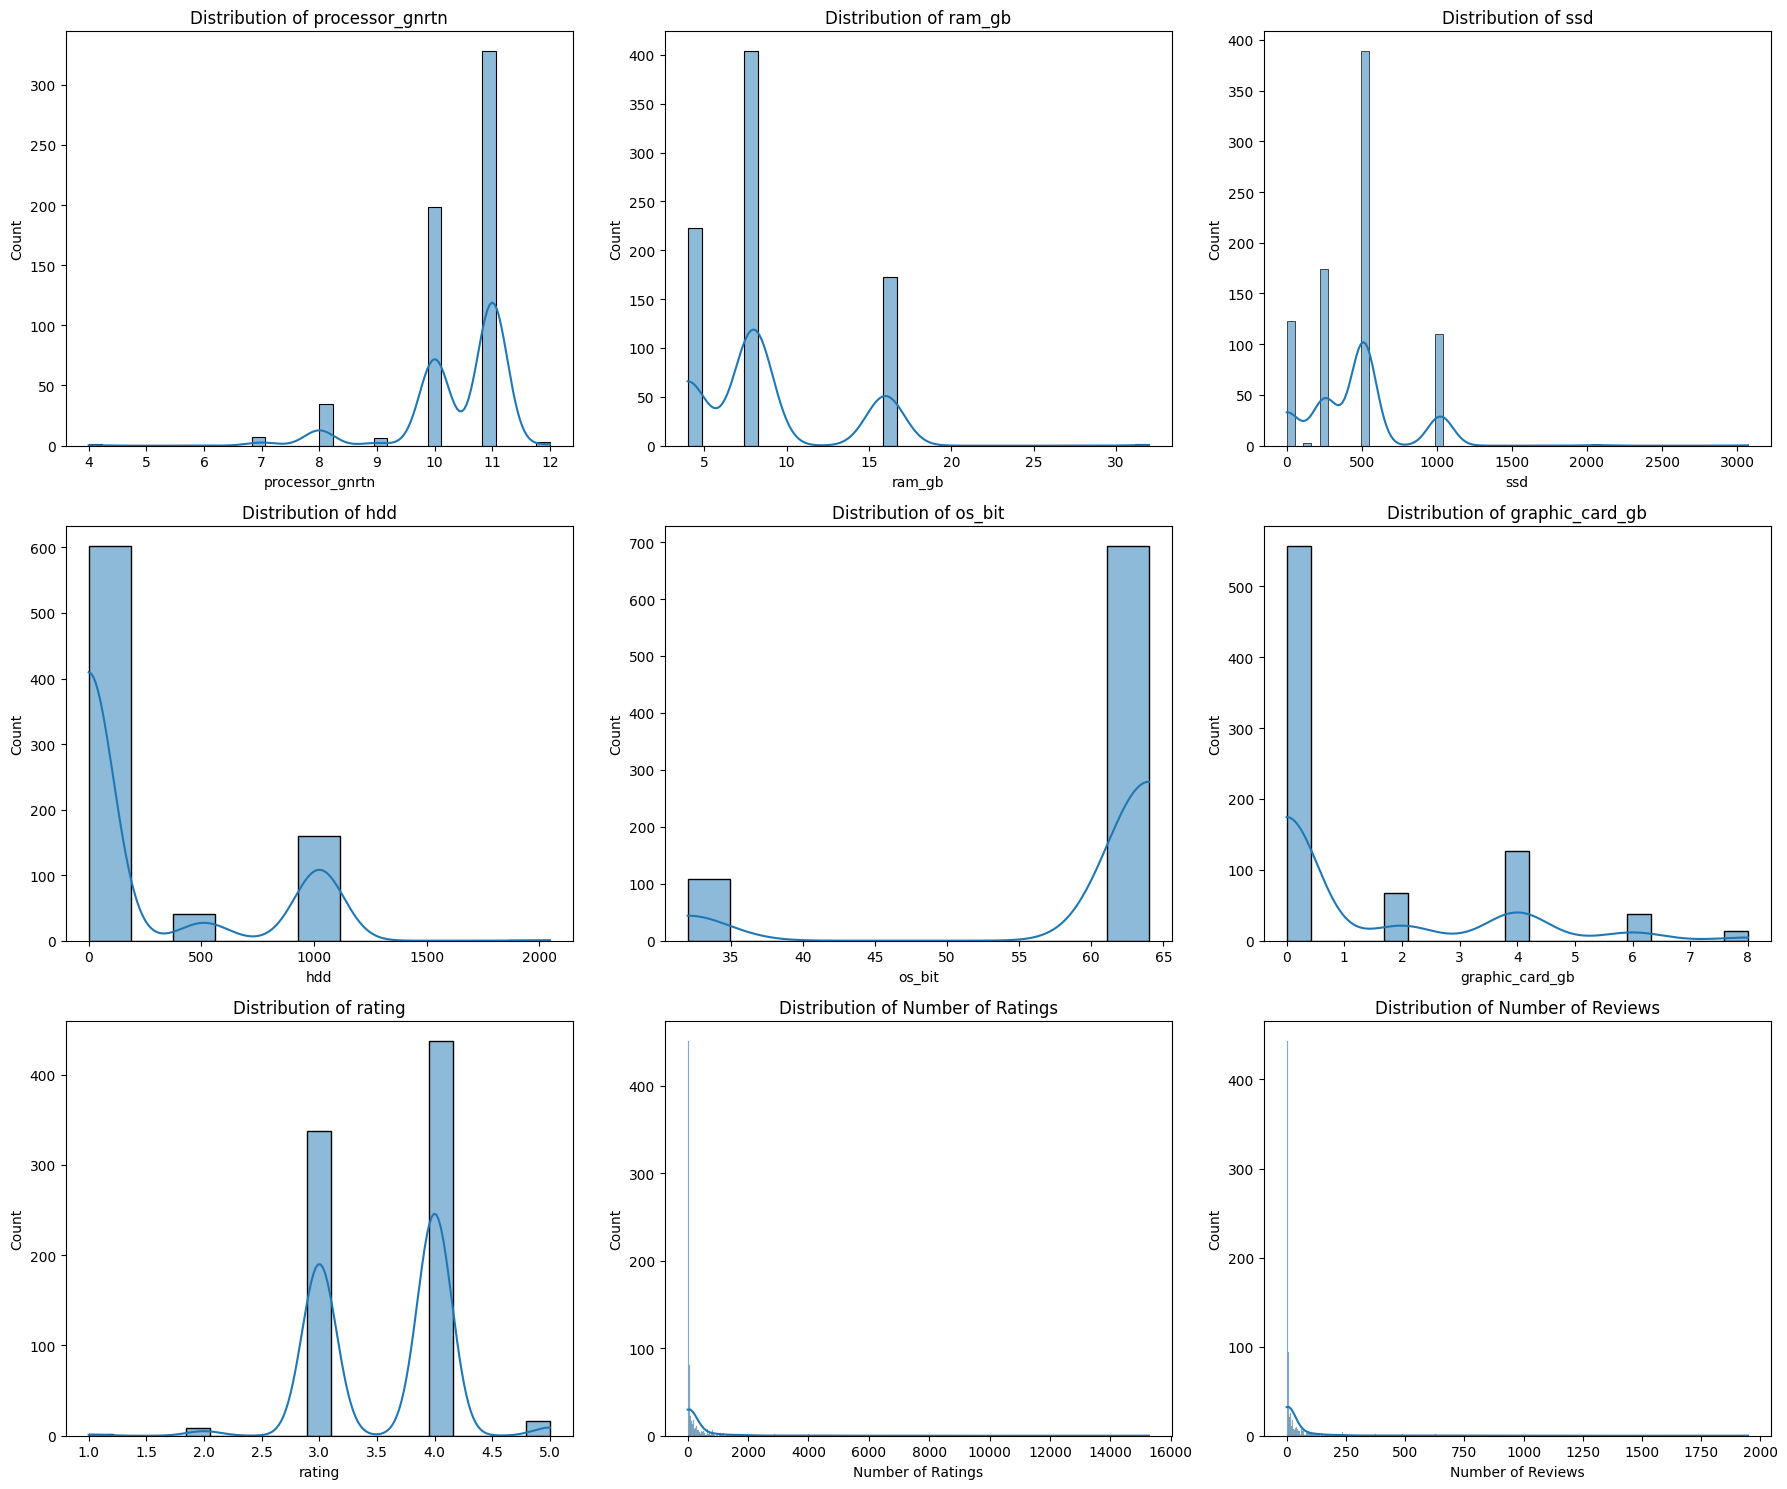

In [107]:
num_cols = df.select_dtypes(include=['int64','float64','int32','float32']).columns.tolist()

# Exclude 'Price' from numerical columns if it's there, as it's often the target variable.
if 'Price' in num_cols:
    num_cols.remove('Price')

num_features = len(num_cols)
num_rows = (num_features + 2) // 3  # Roughly 3 columns per row for better layout

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove any unused subplots if the number of features is not a perfect multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

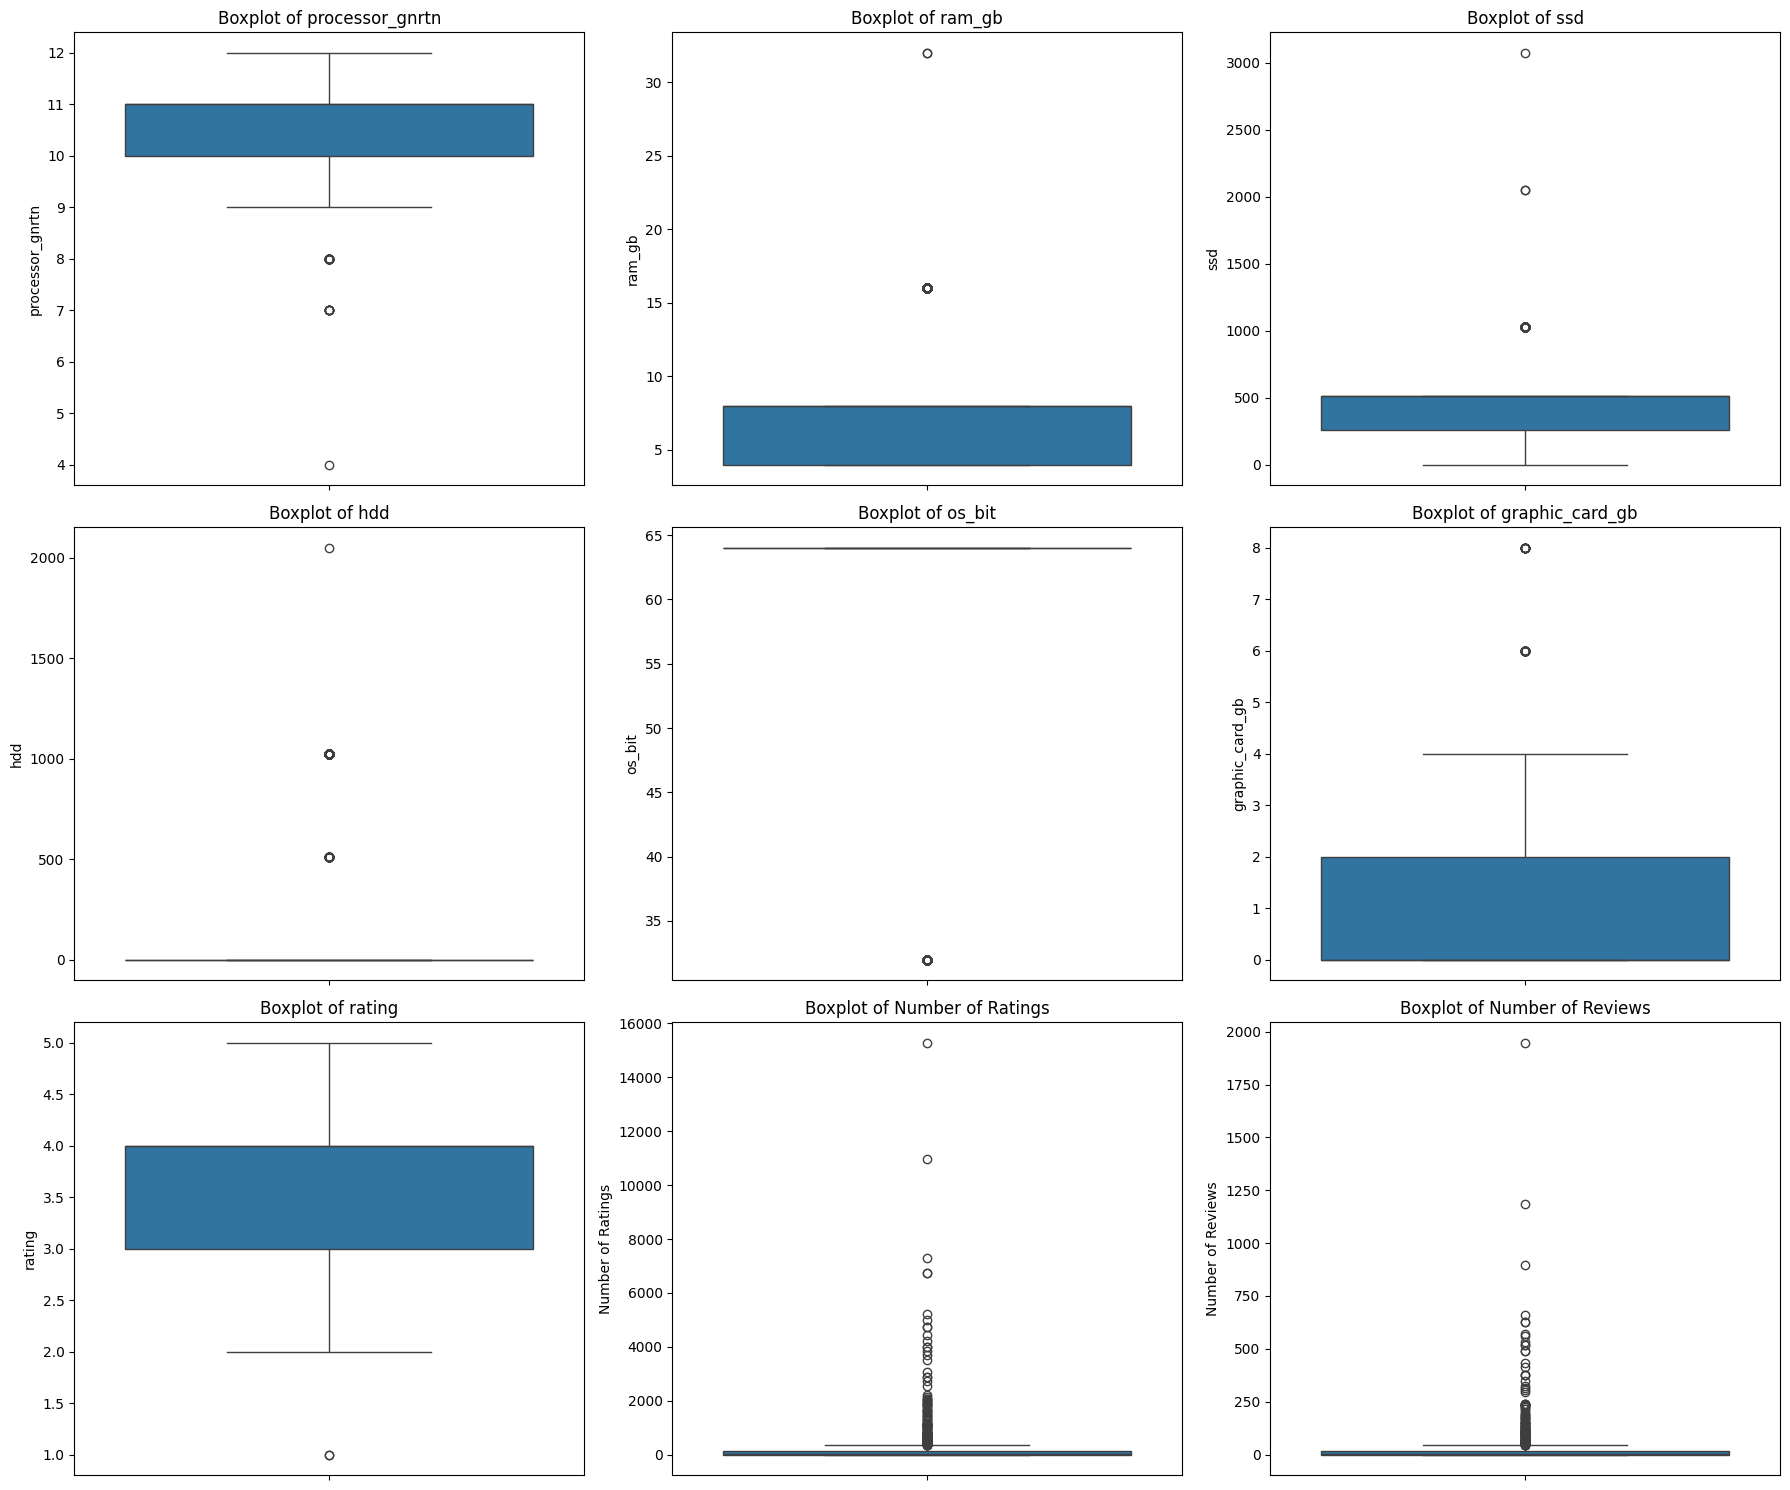

In [108]:
num_cols_for_boxplot = [col for col in numerical_cols if col != 'Price']
num_features_boxplot = len(num_cols_for_boxplot)
num_rows_boxplot = (num_features_boxplot + 2) // 3 # Roughly 3 columns per row

fig, axes = plt.subplots(num_rows_boxplot, 3, figsize=(18, num_rows_boxplot * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_boxplot):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Remove any unused subplots if the number of features is not a perfect multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Bivariant Analysis

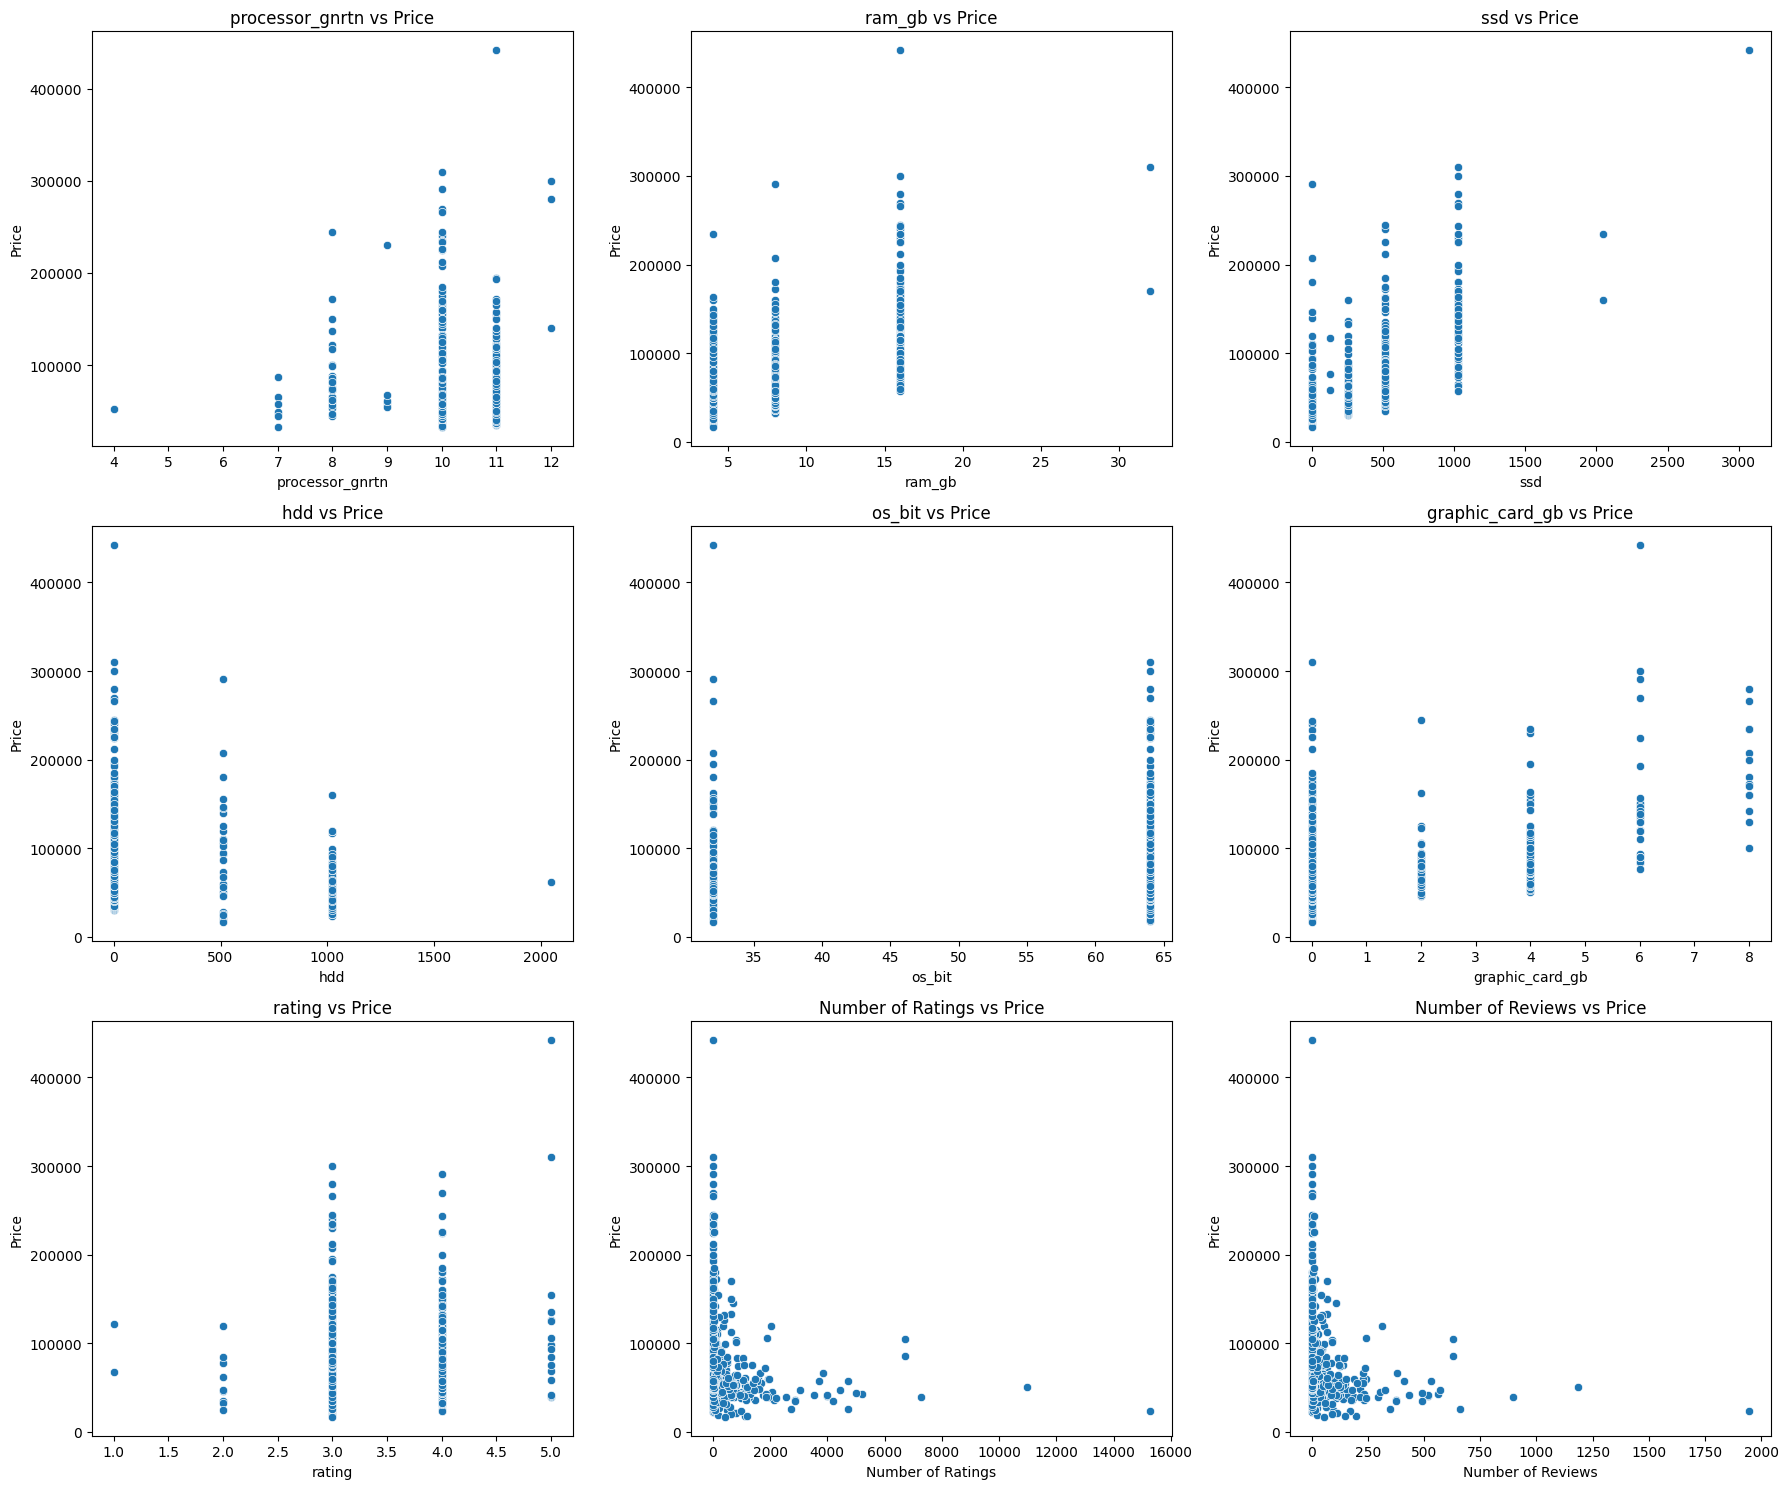

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64','float64','int32','float32']).columns.tolist()

# Remove target variable
if 'Price' in num_cols:
    num_cols.remove('Price')

num_features = len(num_cols)
num_rows = (num_features + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(x=df[col], y=df['Price'], ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

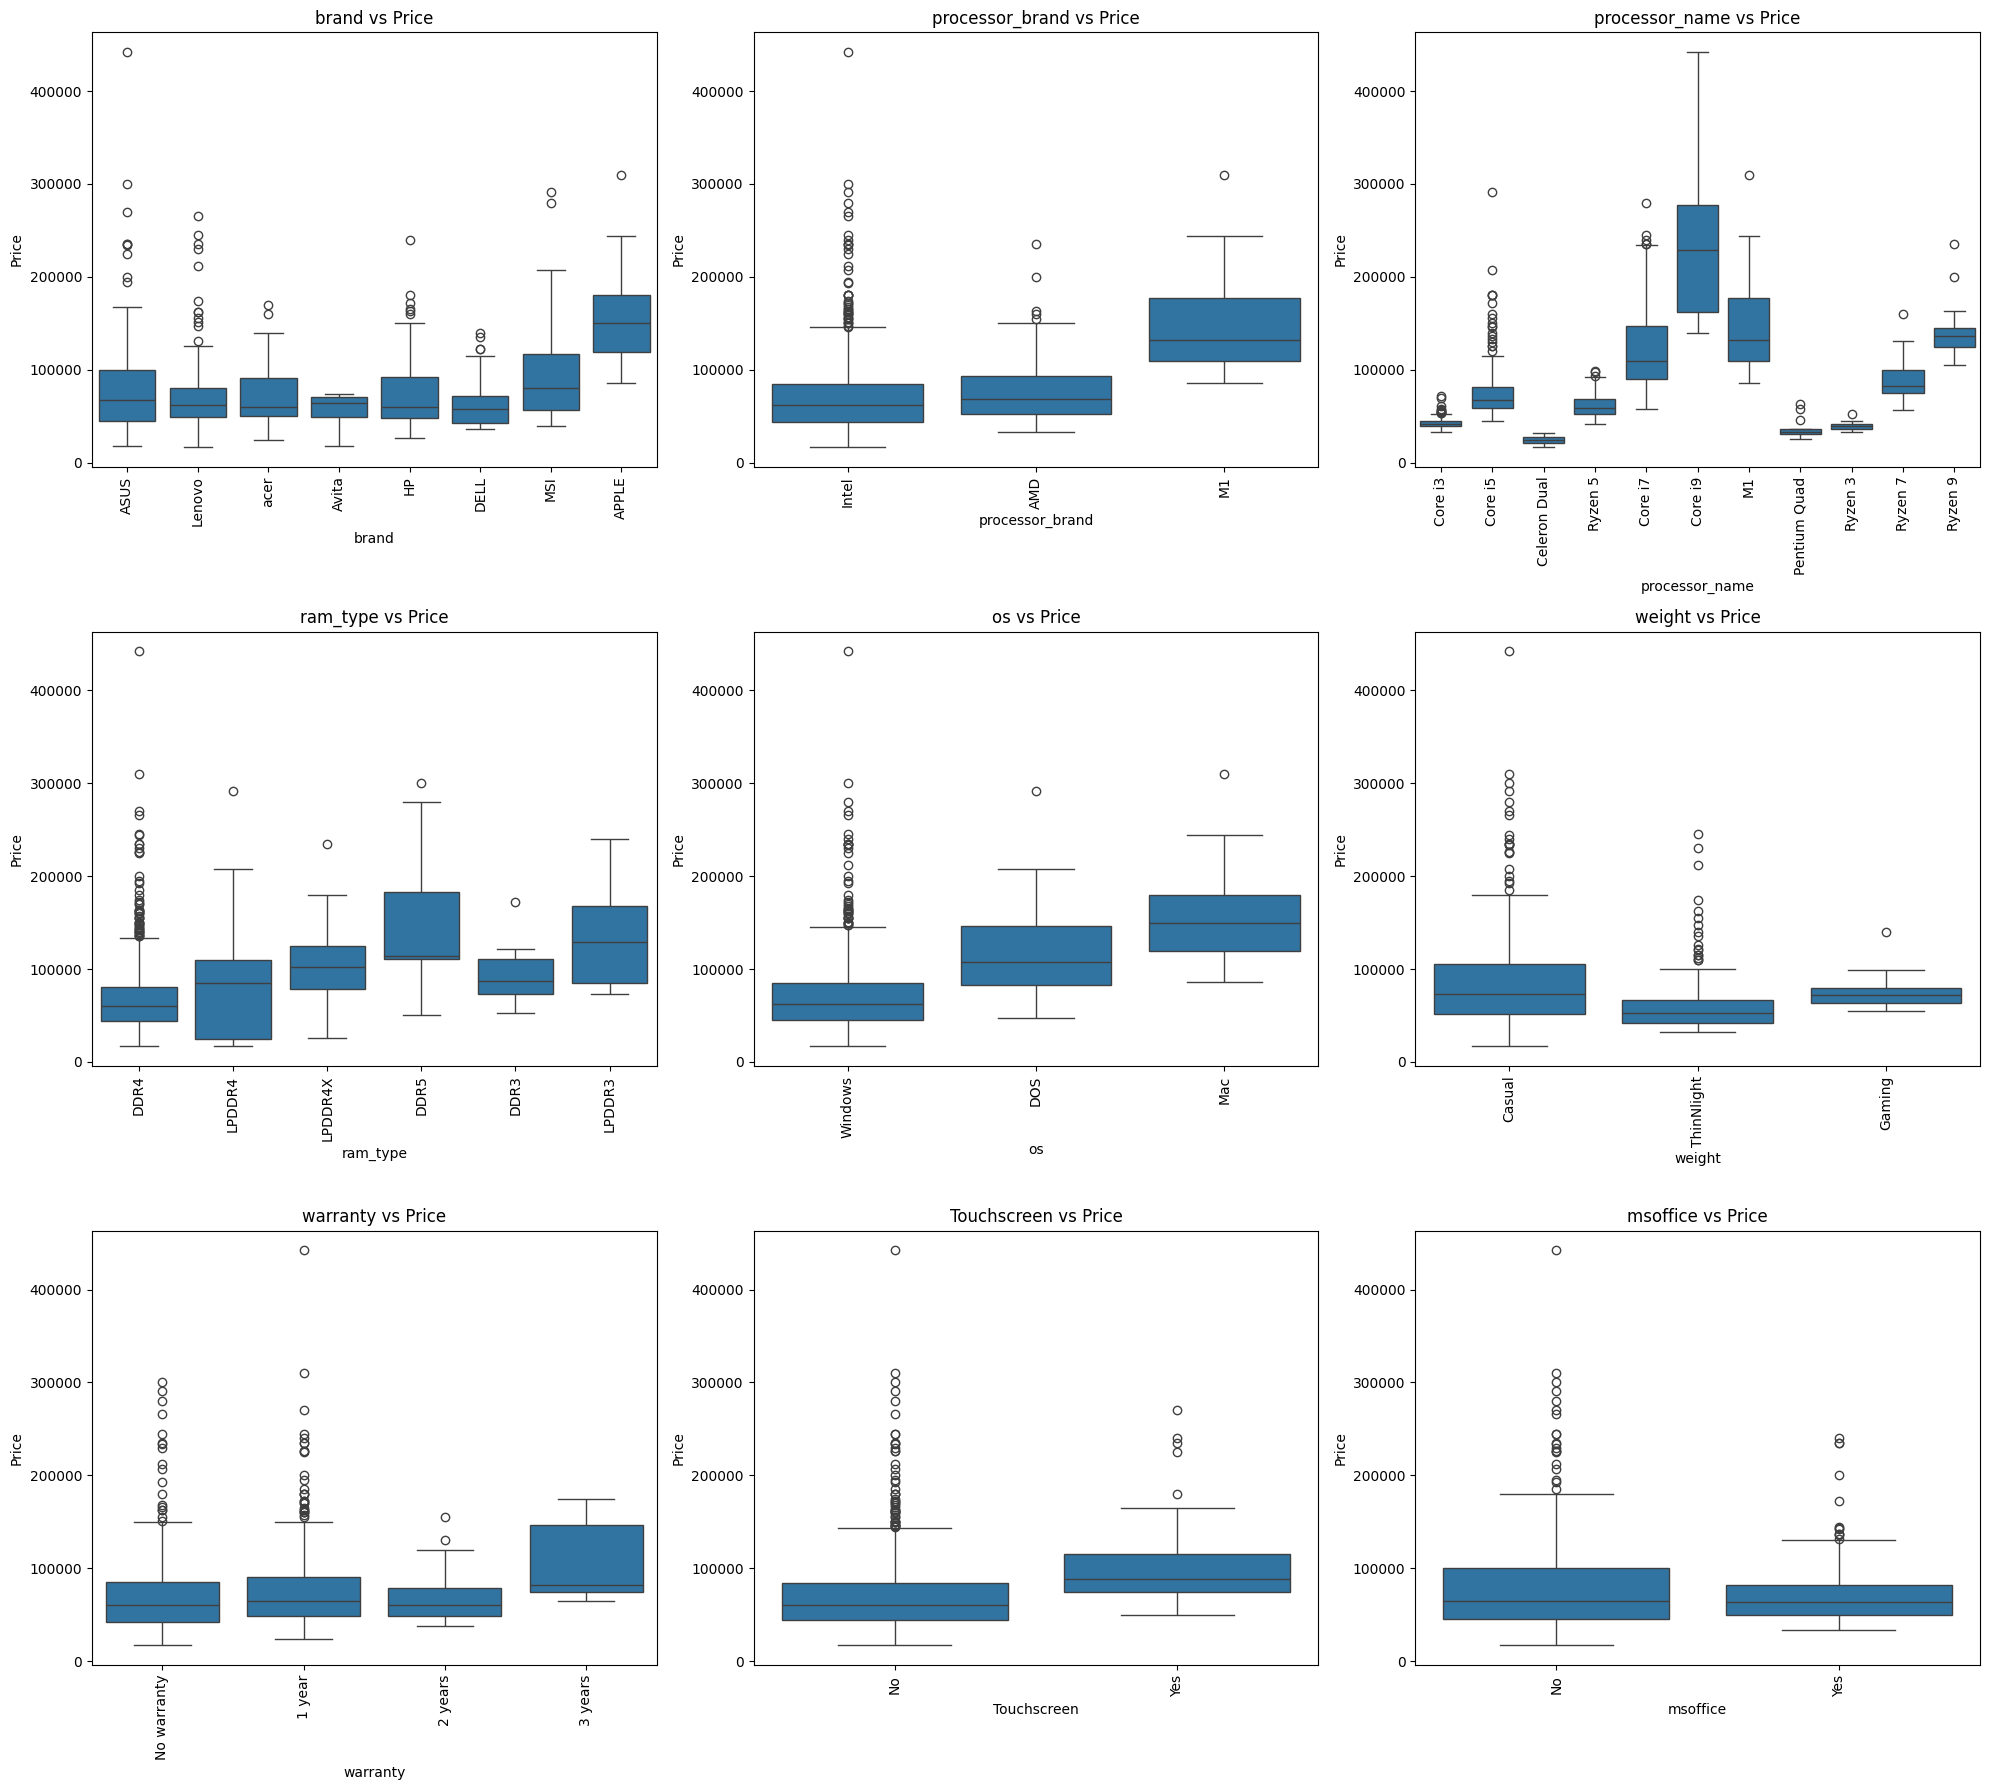

In [110]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_features = len(cat_cols)
num_rows = (num_features + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(20, num_rows * 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col], y=df['Price'], ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    axes[i].tick_params(axis='x', rotation=90)

# Remove extra plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

handle missing value

In [111]:
df['processor_gnrtn'] = df['processor_gnrtn'].fillna(df['processor_gnrtn'].median())

In [112]:
df.isnull().sum()

,0
brand,0
processor_brand,0
processor_name,0
processor_gnrtn,0
ram_gb,0
ram_type,0
ssd,0
hdd,0
os,0
os_bit,0


# **Encoding**

In [113]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

brand: ['ASUS' 'Lenovo' 'acer' 'Avita' 'HP' 'DELL' 'MSI' 'APPLE']
processor_brand: ['Intel' 'AMD' 'M1']
processor_name: ['Core i3' 'Core i5' 'Celeron Dual' 'Ryzen 5' 'Core i7' 'Core i9' 'M1'
 'Pentium Quad' 'Ryzen 3' 'Ryzen 7' 'Ryzen 9']
ram_type: ['DDR4' 'LPDDR4' 'LPDDR4X' 'DDR5' 'DDR3' 'LPDDR3']
os: ['Windows' 'DOS' 'Mac']
weight: ['Casual' 'ThinNlight' 'Gaming']
warranty: ['No warranty' '1 year' '2 years' '3 years']
Touchscreen: ['No' 'Yes']
msoffice: ['No' 'Yes']


In [114]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [115]:
df['Touchscreen'] = le.fit_transform(df['Touchscreen'])
df['msoffice'] = le.fit_transform(df['msoffice'])

In [116]:
#one hot encoding
df=pd.get_dummies(df, columns=[ 'brand',
        'processor_brand',
        'processor_name',
        'ram_type',
        'os',
        'weight',
        'warranty'],drop_first=True)

Check relation

In [117]:
corr = df.corr(numeric_only=True)['Price'].sort_values(ascending=False)
print(corr)

Price                          1.000000
ssd                            0.628734
ram_gb                         0.516454
graphic_card_gb                0.467499
processor_name_Core i7         0.391785
processor_name_Core i9         0.363030
os_Mac                         0.305822
processor_name_M1              0.265689
processor_brand_M1             0.265689
processor_name_Ryzen 9         0.256656
Touchscreen                    0.191227
ram_type_LPDDR3                0.183537
ram_type_LPDDR4X               0.175924
ram_type_DDR5                  0.170677
brand_MSI                      0.125991
warranty_3 years               0.081780
processor_name_Ryzen 7         0.063281
brand_ASUS                     0.040846
ram_type_LPDDR4                0.028823
weight_Gaming                 -0.012061
os_bit                        -0.019731
processor_name_Core i5        -0.021117
brand_acer                    -0.024244
warranty_2 years              -0.029191
brand_HP                      -0.029842


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 822
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   processor_gnrtn              802 non-null    float64
 1   ram_gb                       802 non-null    int32  
 2   ssd                          802 non-null    int32  
 3   hdd                          802 non-null    int32  
 4   os_bit                       802 non-null    int32  
 5   graphic_card_gb              802 non-null    int32  
 6   Touchscreen                  802 non-null    int64  
 7   msoffice                     802 non-null    int64  
 8   Price                        802 non-null    int64  
 9   rating                       802 non-null    int64  
 10  Number of Ratings            802 non-null    int64  
 11  Number of Reviews            802 non-null    int64  
 12  brand_ASUS                   802 non-null    bool   
 13  brand_Avita              

In [119]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

visulize

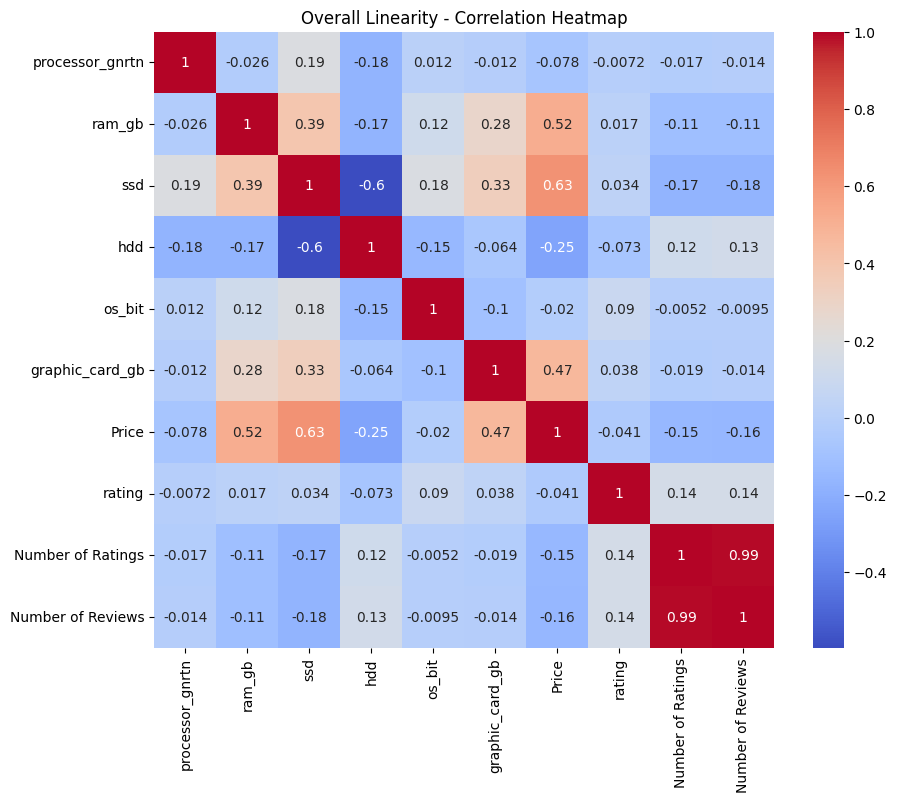

In [120]:
#for numerical
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Overall Linearity - Correlation Heatmap')
plt.show()

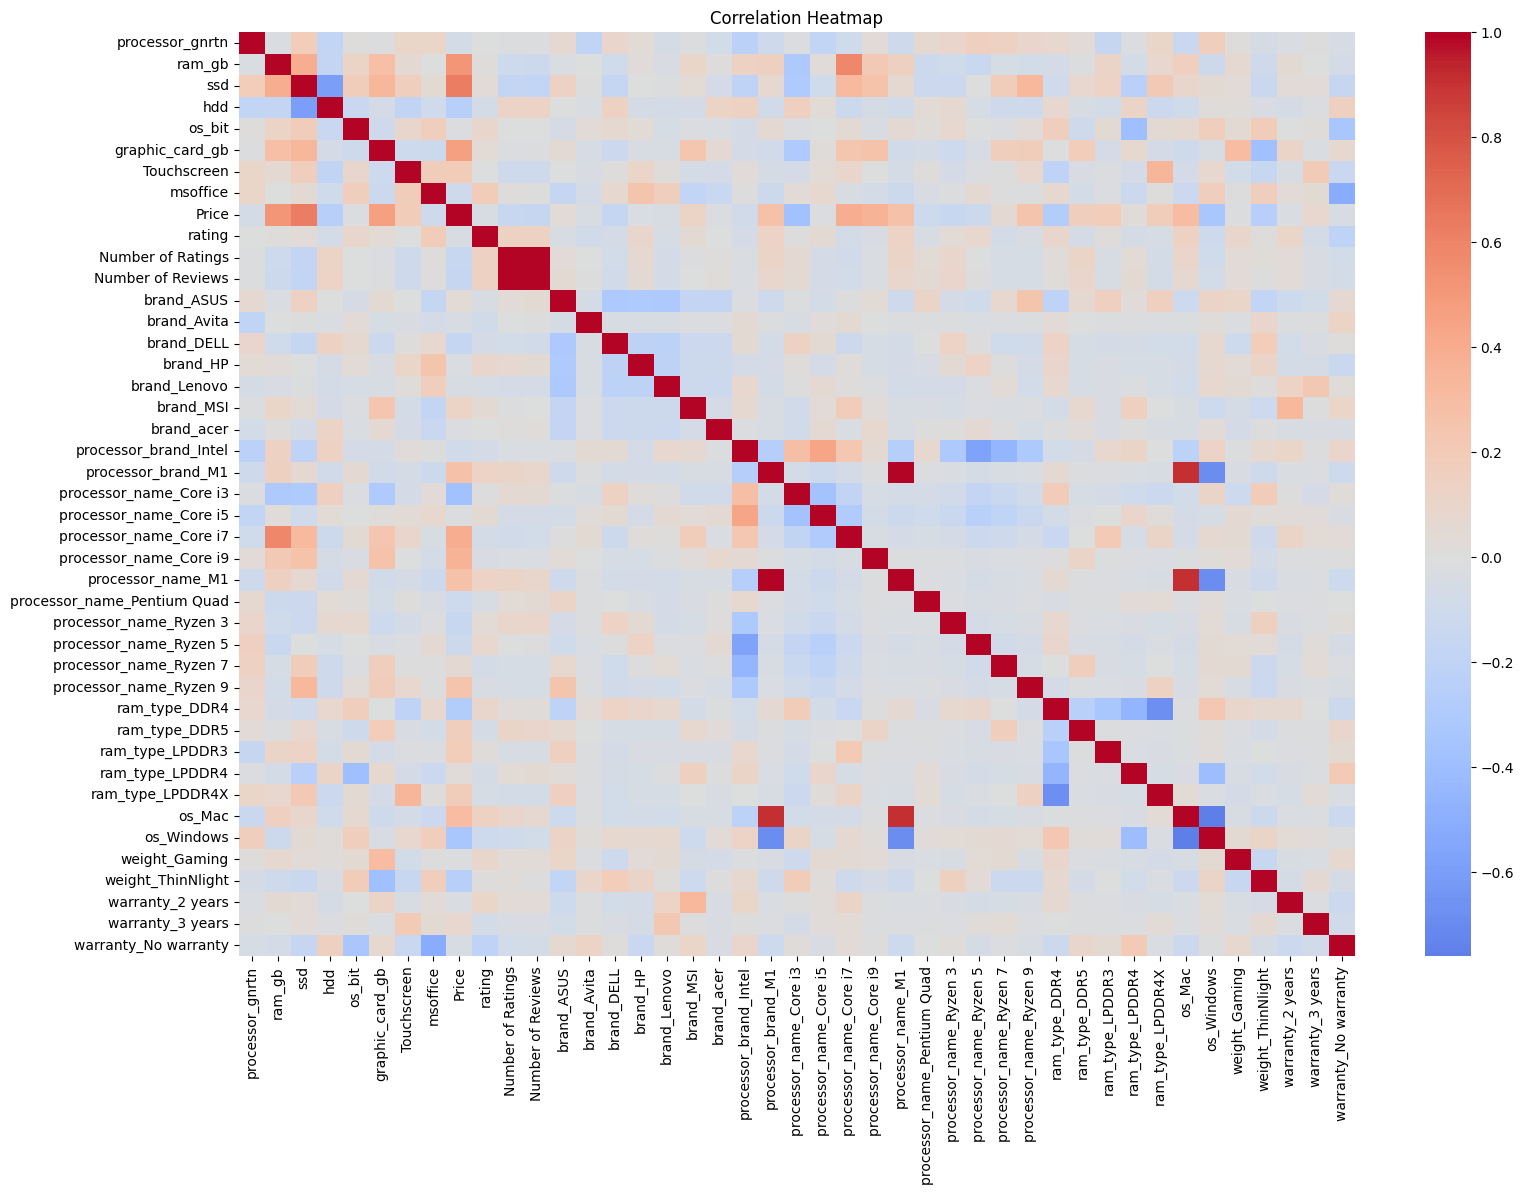

In [121]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()


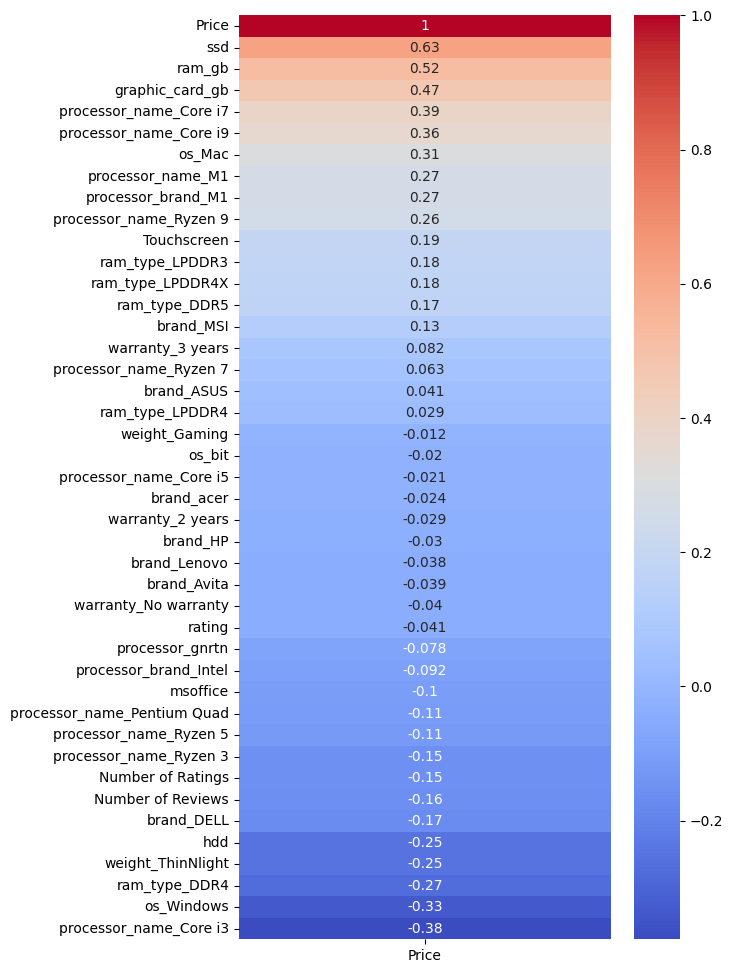

In [122]:
plt.figure(figsize=(6,12))

corr = df.corr()[['Price']].sort_values(by='Price', ascending=False)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [123]:
import numpy as np

df['Price'] = np.log1p(df['Price'])

Model train

In [124]:
X=df.drop('Price',axis=1)
y=df['Price']

In [125]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [126]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [127]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(641, 42)
(161, 42)
(641,)
(161,)


In [128]:
from sklearn.linear_model import LinearRegression


In [129]:
lr=LinearRegression()

In [130]:
lr.fit(X_train, y_train)

LinearRegression()

In [131]:
y_pred = lr.predict(X_test)

In [132]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.14599820994278923
MSE : 0.04277998577810054
RMSE: 0.2068332318030653
R² Score: 0.8160539382712105


In [133]:

results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
196,10.839404,11.174957
299,11.198091,11.115446
171,10.633232,10.613346
537,11.882356,11.848296
551,11.775220,11.722793
809,11.870537,12.021669
610,11.561630,11.596727
328,11.082004,11.289006
222,10.858826,10.880677
415,11.739224,11.516295


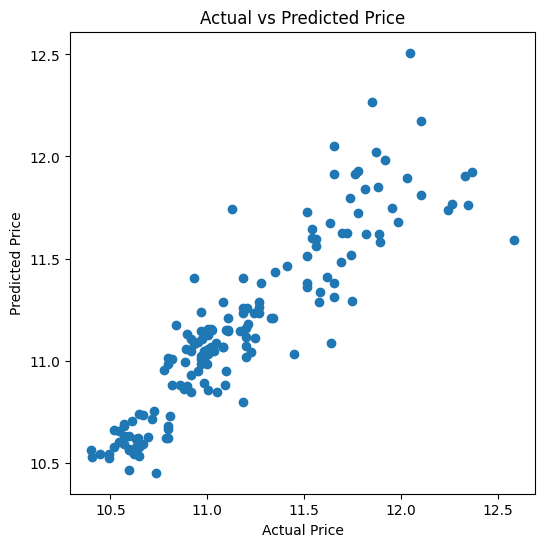

In [134]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

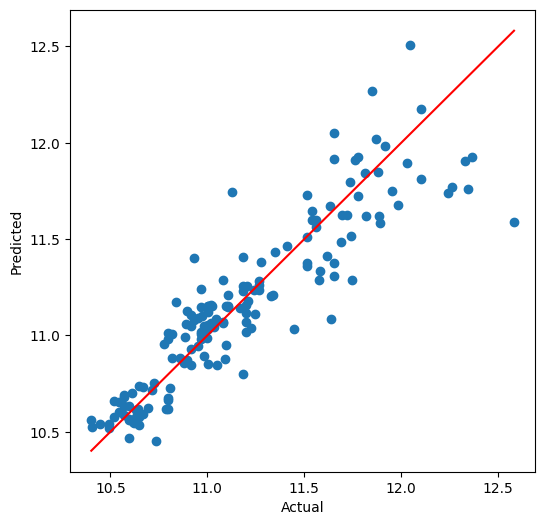

In [135]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [136]:
print("Train Score:", lr.score(X_train, y_train))
print("Test Score :", lr.score(X_test, y_test))

Train Score: 0.8816144561389729
Test Score : 0.8160539382712105


In [137]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results['Error'] = abs(results['Actual'] - results['Predicted'])

results.sort_values('Error', ascending=False).head(10)

,Actual,Predicted,Error
433,12.581735,11.589267,0.992468
200,11.128600,11.742746,0.614146
563,12.345404,11.760480,0.584924
336,11.640360,11.084954,0.555405
477,12.241879,11.738893,0.502986
528,12.263181,11.768166,0.495014
202,10.932946,11.402141,0.469195
587,12.043501,12.508600,0.465099
361,11.744045,11.289361,0.454684
574,12.367302,11.925093,0.442209


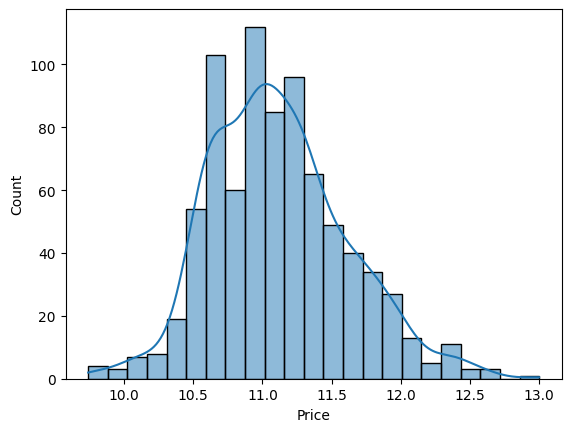

In [138]:
sns.histplot(df['Price'], kde=True)
plt.show()


In [139]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(lr, X_train, y_train, cv=kfold, scoring='r2')
rmse_scores = np.sqrt(-cross_val_score(lr, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error'))

print("CV R² scores:", r2_scores)
print("Mean R²:", r2_scores.mean(), "| Std:", r2_scores.std())
print("Mean RMSE:", rmse_scores.mean())

CV R² scores: [0.83891273 0.8485467  0.86587419 0.8290726  0.86799454]
Mean R²: 0.8500801507347797 | Std: 0.015091436336525375
Mean RMSE: 0.19005218256798082


In [141]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_real_scores = []

for train_idx, val_idx in kfold.split(X_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lr.fit(X_tr, y_tr)
    pred_log = lr.predict(X_val)

    pred_real = np.expm1(pred_log)
    val_real = np.expm1(y_val)

    rmse_real_scores.append(mean_squared_error(val_real, pred_real) ** 0.5)

print("Mean RMSE (₹):", np.mean(rmse_real_scores))

Mean RMSE (₹): 20240.942115574282


In [143]:
print("Average Price (₹):", np.expm1(df['Price']).mean())

Average Price (₹): 76625.54364089775


# **Pipeline Approach (Production-ready version)**

In [144]:
# ================= PIPELINE VERSION (for deployment) =================
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# Fresh load — original raw price, one-hot na hua hua data
df_deploy = pd.read_csv('laptopPrice.csv')

# ---- same cleaning steps jo aapne upar ki thi ----
df_deploy.drop_duplicates(inplace=True)
df_deploy['processor_gnrtn'] = df_deploy['processor_gnrtn'].str.replace('th', '', regex=False)
df_deploy['processor_gnrtn'] = pd.to_numeric(df_deploy['processor_gnrtn'], errors='coerce')
df_deploy['ram_gb'] = df_deploy['ram_gb'].str.replace('GB', '', regex=False).astype('int32')
df_deploy['hdd'] = df_deploy['hdd'].str.replace('GB', '', regex=False).astype('int32')
df_deploy['os_bit'] = df_deploy['os_bit'].str.replace('-bit', '', regex=False).astype('int32')
df_deploy['ssd'] = df_deploy['ssd'].astype(str).str.replace('GB', '', regex=False)
df_deploy['ssd'] = pd.to_numeric(df_deploy['ssd'], errors='coerce').astype('int32')
df_deploy['graphic_card_gb'] = df_deploy['graphic_card_gb'].str.replace('GB', '', regex=False).astype('int32')
df_deploy['rating'] = df_deploy['rating'].str.replace(' stars', '', regex=False).str.replace(' star', '', regex=False)
df_deploy['rating'] = pd.to_numeric(df_deploy['rating'], errors='coerce')
df_deploy['processor_gnrtn'] = df_deploy['processor_gnrtn'].fillna(df_deploy['processor_gnrtn'].median())
df_deploy['Touchscreen'] = df_deploy['Touchscreen'].map({'No': 0, 'Yes': 1})
df_deploy['msoffice'] = df_deploy['msoffice'].map({'No': 0, 'Yes': 1})

# ---- Pipeline ----
X = df_deploy.drop('Price', axis=1)
y = df_deploy['Price']   # raw price — Pipeline khud log1p/expm1 karega

categorical_cols = ['brand', 'processor_brand', 'processor_name', 'ram_type', 'os', 'weight', 'warranty']
binary_cols = ['Touchscreen', 'msoffice']
numeric_cols = [col for col in X.columns if col not in categorical_cols + binary_cols]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols + binary_cols),
])

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline = TransformedTargetRegressor(
    regressor=base_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("MAE (₹):", mean_absolute_error(y_test, y_pred))
print("RMSE (₹):", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²:", r2_score(y_test, y_pred))

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='r2')
print("CV Mean R²:", cv_r2.mean(), "| Std:", cv_r2.std())

# ---- Save for deployment ----
joblib.dump(pipeline, 'pipeline.pkl')
print("pipeline.pkl saved ✅")

MAE (₹): 14501.436120151817
RMSE (₹): 27568.670752993505
R²: 0.6427193542701519
CV Mean R²: 0.7870826752275057 | Std: 0.05178134296548967
pipeline.pkl saved ✅
